In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

DATA READING

In [13]:
import pandas as pd
df = pd.read_csv('insurance.csv')

EDA

In [14]:
df.shape
df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Visualization in EDA

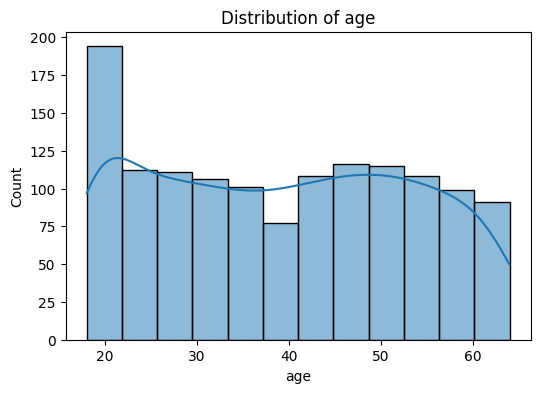

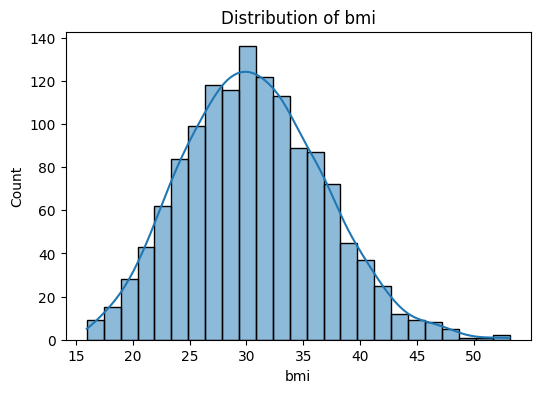

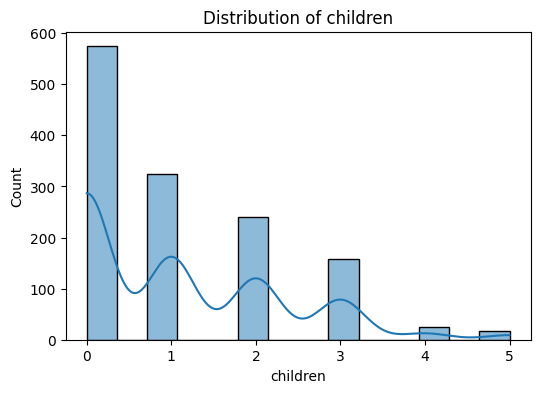

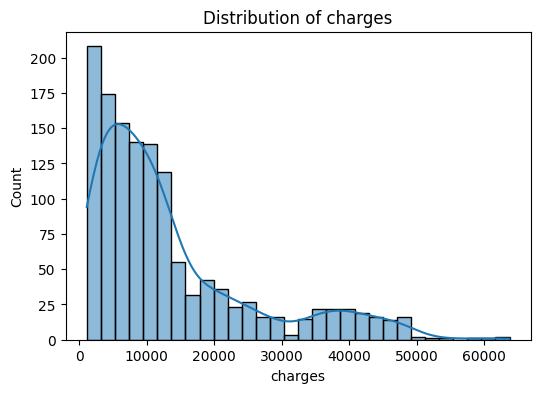

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols = ['age', 'bmi', 'children', 'charges']
for col in numeric_cols :
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


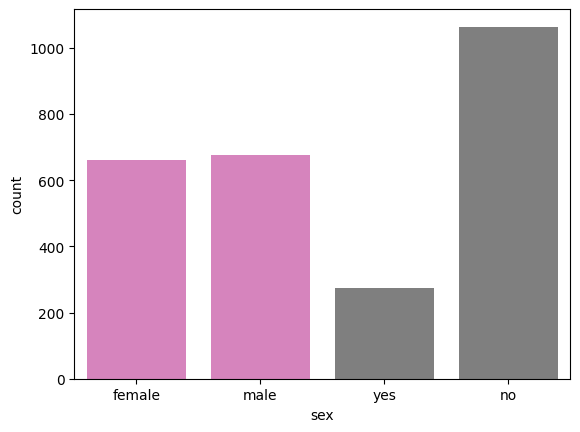

In [16]:
for col in numeric_cols :
    sns.countplot(x=df['sex'])
    sns.countplot(x=df['smoker'])

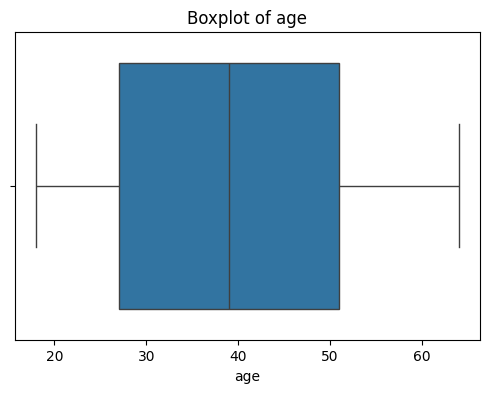

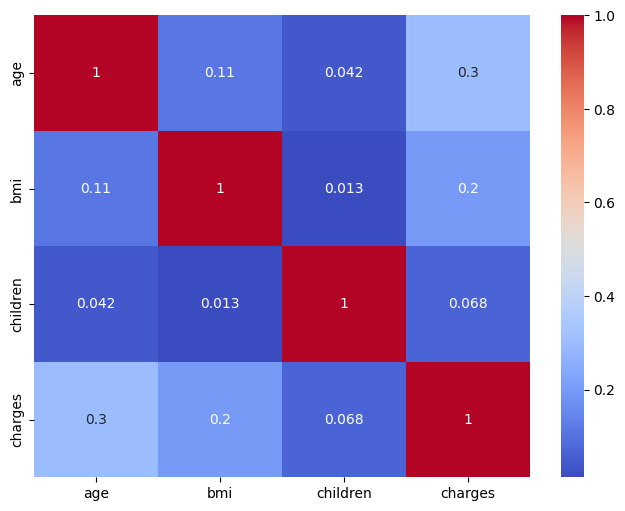

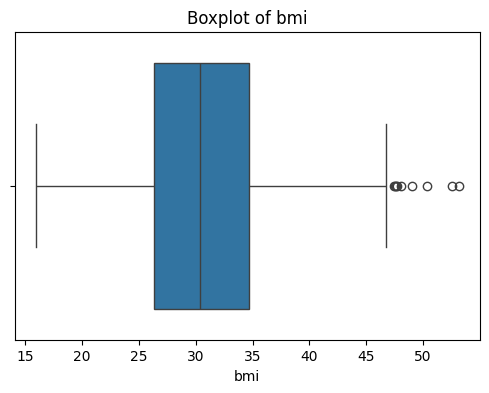

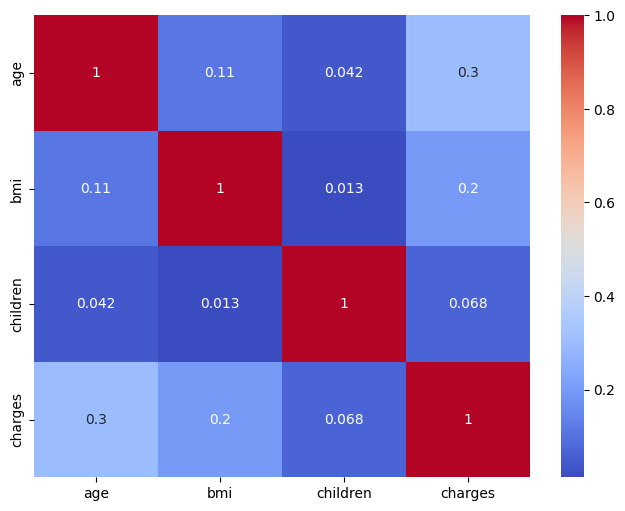

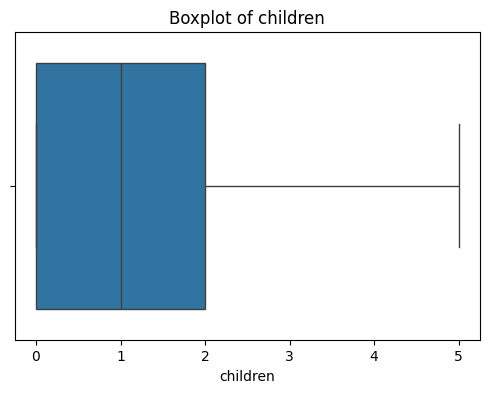

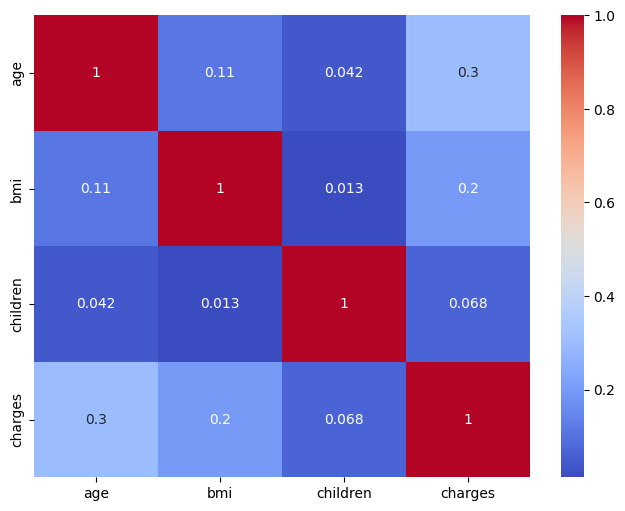

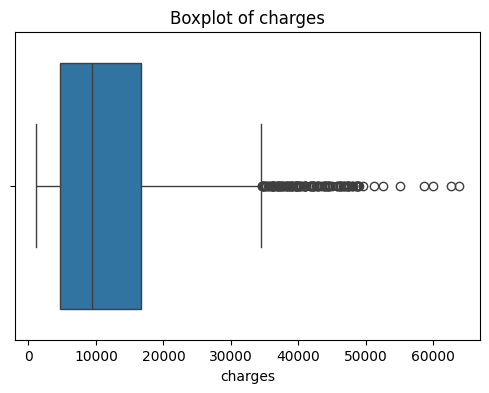

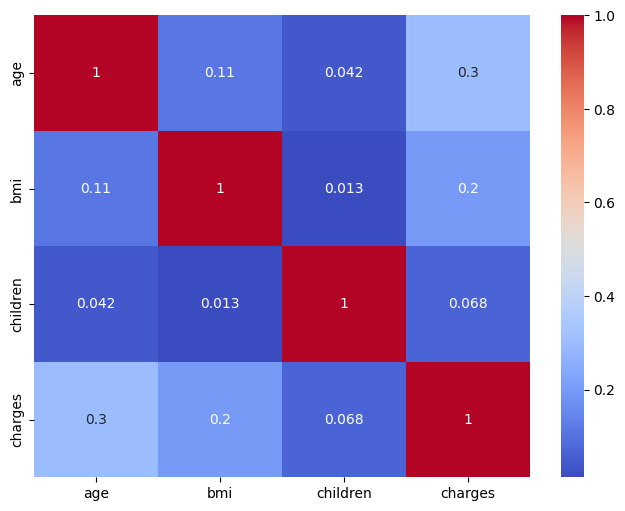

In [17]:
for col in numeric_cols :
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.figure(figsize=(8,6))
    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
    plt.show()

Data Cleaning And Preprocessing

In [18]:
df_cleaned = df.copy()
df_cleaned.drop_duplicates(inplace=True)

In [19]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [20]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [21]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [22]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

Label Encoding

In [23]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male': 0, 'female': 1})

In [24]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [25]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'yes': 1, 'no': 0})

In [26]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [27]:
df_cleaned.rename(columns={
    'sex': 'is_female',
    'smoker': 'is_smoker'
}, inplace=True)

In [28]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

One hot Encoding

In [29]:
df_cleaned = pd.get_dummies(df_cleaned, columns = ['region'], drop_first=True)

In [30]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [31]:
df_cleaned = df_cleaned.astype(int)

In [32]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


Feature Engineering and extraction

<Axes: xlabel='bmi', ylabel='Count'>

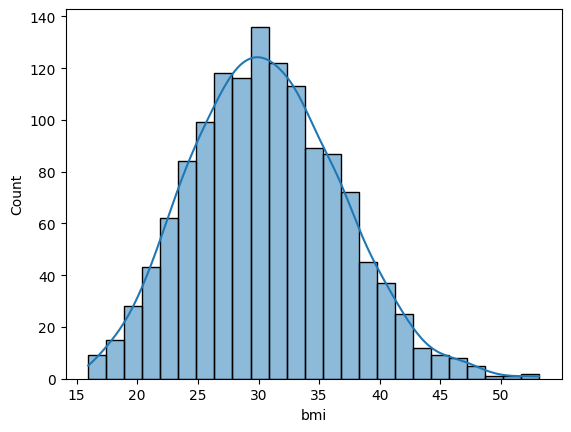

In [33]:
sns.histplot(df['bmi'], kde=True)

In [34]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal weight', 'Overweight', 'Obesity']
)

In [108]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obesity
2,28,0,33,3,0,4449,0,1,0,Obesity
3,33,0,22,0,0,21984,1,0,0,Normal weight
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,Obesity
1334,18,1,31,0,0,2205,0,0,0,Obesity
1335,18,1,36,0,0,1629,0,1,0,Obesity
1336,21,1,25,0,0,2007,0,0,1,Overweight


In [35]:
df_cleaned = pd.get_dummies(df_cleaned, columns = ['bmi_category'], drop_first=True)

In [36]:
df_cleaned.astype(int)

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obesity
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


Feature Scaling

In [37]:
from sklearn.preprocessing import StandardScaler
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [38]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obesity
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,False,True,False
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,False,False,True
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,False,False,True
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,True,False,False
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,False,True,False


In [39]:
from scipy.stats import pearsonr
selected_features = ['age', 'bmi', 'children', 'is_female', 'is_smoker',
                     'region_northwest', 'region_southeast', 'region_southwest','bmi_category_Normal weight',
                     'bmi_category_Overweight', 'bmi_category_Obesity']

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation with Charges'])
correlation_df.sort_values(by='Pearson Correlation with Charges', ascending=False)

,Feature,Pearson Correlation with Charges
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_Obesity,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_female,-0.058046
8,bmi_category_Normal weight,-0.104042


In [40]:
cat_features = [
    'is_female', 'is_smoker', 'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal weight', 'bmi_category_Overweight', 'bmi_category_Obesity'
]

Chi Square Test

In [41]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_binned'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency_table = pd.crosstab(df_cleaned[col], df_cleaned['charges_binned'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    decision = 'Reject Null (Keep Feature)' if p < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'Chi2 Statistic': chi2,
        'p-value': p,
        'Degrees of Freedom': dof,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p-value')
chi2_df

,Chi2 Statistic,p-value,Degrees of Freedom,Decision
is_smoker,848.219178,0.0,3,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,3,Reject Null (Keep Feature)
is_female,10.258784,0.01649,3,Reject Null (Keep Feature)
bmi_category_Obesity,8.515711,0.036473,3,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,3,Accept Null (Drop Feature)
bmi_category_Overweight,4.25149,0.235557,3,Accept Null (Drop Feature)
bmi_category_Normal weight,3.708088,0.29476,3,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,3,Accept Null (Drop Feature)


In [42]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
                     'region_southwest', 'bmi_category_Obesity']]

In [43]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southwest,bmi_category_Obesity
0,-1.440418,1,-0.517949,-0.909234,1,16884,1,False
1,-1.511647,0,0.462463,-0.079442,0,1725,0,True
2,-0.799350,0,0.462463,1.580143,0,4449,0,True
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,False
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,False
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,True
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,True
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,True
1336,-1.297958,1,-0.844753,-0.909234,0,2007,1,False


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [47]:
X = final_df.drop("charges", axis=1)
y = final_df["charges"]

Train Test Split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Model 1 — Linear Regression

In [49]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

Evaluation

In [50]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 4298.38441391229
MSE: 35974911.44201296
R2 Score: 0.8042246523654484


Model 2 — Random Forest (Better Model)

In [51]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Evaluation

In [52]:
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

MAE: 2825.9996687766525
MSE: 23155738.50408421
R2 Score: 0.8739865485790284


Prediction Example

In [53]:
sample = X_test.iloc[0].values.reshape(1,-1)

prediction = rf.predict(sample)

print("Predicted Charges:", prediction)
print("Actual Charges:", y_test.iloc[0])

Predicted Charges: [8872.13]
Actual Charges: 8688


Feature Importance

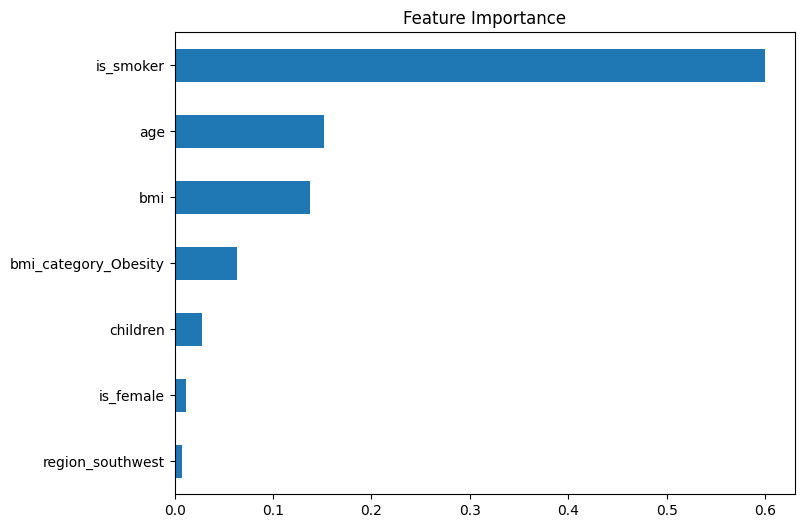

In [54]:
importance = rf.feature_importances_

features = pd.Series(importance, index=X.columns)

features.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Importance")
plt.show()

Model Performance Visualization

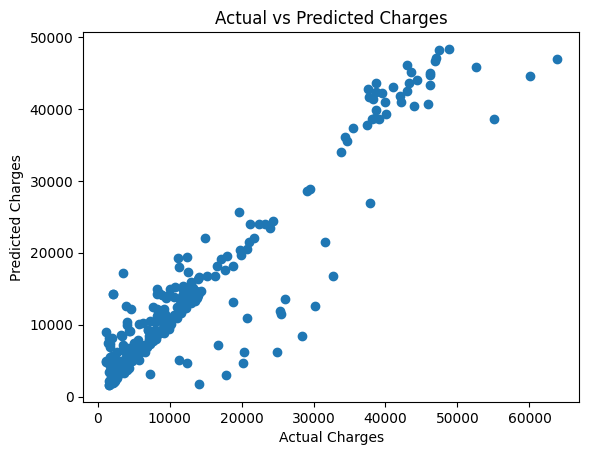

In [55]:
plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Charges")

plt.show()